### Bienvenido al Taller Online de PWF: Leyendo y Manipulando Datos Abiertos de LHCb

El propósito de este cuaderno es realizar un breve ejercicio para comprobar que tu entorno conda de LHCb está listo para leer y ejecutar Datos Abiertos del LHC.

In [1]:
import numpy as np
import pandas as pd
import uproot
import os
from matplotlib import pyplot as plt
from subprocess import check_output

Descarguemos un archivo con datos simulados de producción del bosón de Higgs en el Modelo Estándar desintegrándose en cuatro leptones. No te preocupes si no estás familiarizado con el proceso; lo usaremos solo para probar si tu entorno conda funciona.

In [2]:
filename = 'SMHiggsToZZTo4L.root'
fn_url = 'root://eospublic.cern.ch//eos/root-eos/cms_opendata_2012_nanoaod/'+filename

# Creating Data folder
if not os.path.exists('./Data/'): os.makedirs('./Data/')

#Downloading data file
if not os.path.isfile('./Data/'+filename):
    print('Downloading', fn_url)
    check_output('xrdcp ' + fn_url + ' ./Data/', shell=True)

Guardaremos los datos simulados como un data frame incluyendo un corte de selección para obtener un data frame más pequeño. Centrémonos en eventos con dos electrones y dos muones en el estado final. `nElectron` es el número de electrones y `nMuon` es el número de muones de cada evento.

In [4]:
# Selection cuts
preselection = "(nElectron==2) & (nMuon==2)"

# Saving selected events of de simulated data as data frame
with uproot.open("./Data/SMHiggsToZZTo4L.root:Events") as rootdata:
    data = rootdata.arrays(rootdata.keys(),preselection,library="pd")

Veamos qué información está disponible para cada evento.

In [5]:
print(data.keys())

Index(['run', 'luminosityBlock', 'event', 'PV_npvs', 'PV_x', 'PV_y', 'PV_z',
       'nMuon', 'Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_mass', 'Muon_charge',
       'Muon_pfRelIso03_all', 'Muon_pfRelIso04_all', 'Muon_tightId',
       'Muon_softId', 'Muon_dxy', 'Muon_dxyErr', 'Muon_dz', 'Muon_dzErr',
       'nElectron', 'Electron_pt', 'Electron_eta', 'Electron_phi',
       'Electron_mass', 'Electron_charge', 'Electron_pfRelIso03_all',
       'Electron_dxy', 'Electron_dxyErr', 'Electron_dz', 'Electron_dzErr'],
      dtype='str')


Y finalmente, tracemos el histograma del momento transverso de los dos electrones.

/tmp/ipykernel_47438/1055579978.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(data['Electron_pt'],50,[0,150])


(array([[0.000e+00, 9.110e+02, 2.496e+03, 2.868e+03, 2.704e+03, 2.585e+03,
         2.188e+03, 1.805e+03, 1.579e+03, 1.512e+03, 1.441e+03, 1.476e+03,
         1.442e+03, 1.458e+03, 1.310e+03, 1.129e+03, 9.440e+02, 7.370e+02,
         5.030e+02, 3.650e+02, 2.550e+02, 2.070e+02, 1.640e+02, 1.150e+02,
         1.070e+02, 7.700e+01, 8.000e+01, 6.200e+01, 5.000e+01, 3.700e+01,
         3.100e+01, 3.800e+01, 1.600e+01, 2.300e+01, 2.200e+01, 1.300e+01,
         1.700e+01, 1.100e+01, 6.000e+00, 8.000e+00, 9.000e+00, 3.000e+00,
         5.000e+00, 5.000e+00, 5.000e+00, 4.000e+00, 5.000e+00, 2.000e+00,
         6.000e+00, 4.000e+00],
        [0.000e+00, 1.147e+03, 2.989e+03, 2.827e+03, 2.721e+03, 2.415e+03,
         1.988e+03, 1.785e+03, 1.505e+03, 1.486e+03, 1.416e+03, 1.442e+03,
         1.482e+03, 1.365e+03, 1.273e+03, 1.100e+03, 8.330e+02, 6.870e+02,
         4.960e+02, 4.020e+02, 2.860e+02, 2.200e+02, 1.540e+02, 1.460e+02,
         1.180e+02, 8.700e+01, 7.600e+01, 5.100e+01, 4.500e+01, 4.50

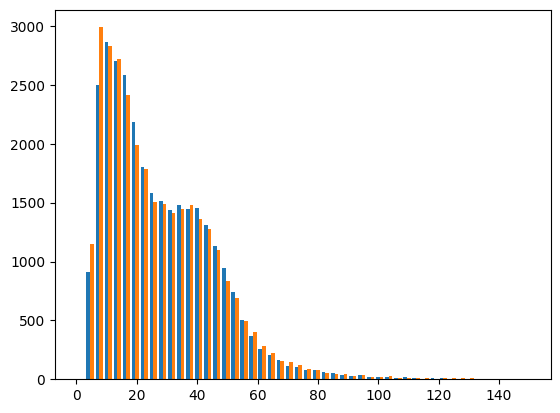

In [6]:
plt.hist(data['Electron_pt'],50,[0,150])

**¡Felicitaciones!**, tu entorno conda está listo.